# Find the SWOT satellite fly-by time through a bounding box.  

Notebook adapted from python script find_swot_passes_science.py by Jinbo Wang provided on https://github.com/SWOT-community/SWOT-OpenToolkit/tree/main/src 

**Has to run on geopandas kernel**

In [127]:
"""
Find the SWOT satellite fly-by time through a bounding box. 
The time will have uncertainty of tens of seconds to minutes depending on 
the size of the bounding box.

Make sure download the two shapefile associated with the SWOT orbit data from the aviso website. You can use the included script to download the data.
    bash download_swot_orbit.sh

Usage:
    python find_swot_passes_science.py -sw_corner -130.0 35.0 -ne_corner -125.0 40.0 -output_filename /tmp/test.png

Author: Jinbo Wang
Date: 2021-07-21
"""

# =============================================================================
# Imports
# =============================================================================
import geopandas as gpd
import pandas as pd
import shapely.geometry as geometry
from datetime import timedelta
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import box, LineString, Point
from shapely.ops import unary_union
import numpy as np
import os, argparse
import xarray as xr
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append("/home/sryan/python/")  # add custom utilities path
from utils.plot_utils import finished_plot

# extract ice shelves for plotting
from cartopy.feature import NaturalEarthFeature
ice_shelves = NaturalEarthFeature(
    category='physical',
    name='antarctic_ice_shelves_polys',
    scale='10m',
    facecolor='lightblue',
    edgecolor='black'
)

# =============================================================================
# Data loading: Bathymetry
# =============================================================================
# Load bathymetry data (ETOPO1). Subsetting can be used for faster plotting.
bathy = xr.open_dataset(
    '/vast/clidex/data/bathymetry/ETOPO1/ETOPO1_Bed_g_gmt4.grd'
).sel(y=slice(-80,-60)).load()


# =============================================================================
# File paths and required orbit data checks
# =============================================================================
# Base directory containing SWOT orbit shapefiles
filepath = '/srv/data/SWOT/'

# Check that required orbit shapefile zip archives exist (download if missing)
if os.path.exists(filepath + "/sph_calval_nadir.zip") is False or os.path.exists(filepath + "/sph_science_swath.zip") is False:
    print("Please download the two shapefiles associated with the SWOT orbit data from the aviso website using the included script.\n")
    print("bash download_swot_orbit_data.sh\n")
    exit()


# =============================================================================
# Command line parsing (currently commented out)
# =============================================================================
# parser = argparse.ArgumentParser(description='Find the SWOT satellite fly-by time through a bounding box.')
# parser.add_argument('-sw_corner', type=float, nargs=2, help='The southwest corner of the bounding box [lon, lat]')
# parser.add_argument('-ne_corner', type=float, nargs=2, help='The northeast corner of the bounding box [lon, lat]')
# parser.add_argument('-cycles', type=int, nargs=2, help='First and last cycle number [cycle_start, cycle_end]')
# parser.add_argument('-output_filename', type=str, help='The filename of the figure to save. e.g. test.png')
# args = parser.parse_args()



# =============================================================================
# Region definitions (manual overrides)
# =============================================================================
# --- MAB ---
sw_corner_MAB = [-77,35]  # args.sw_corner
ne_corner_MAB = [-60,47]  # args.ne_corner
# # cycles = [1,31]
# output_filename = 'calval_passIDs_MAB_GoM.png'  # subplot with individual passIDs

# --- Weddell Sea ---
sw_corner_Weddell = [-62, -80]   # [lon, lat]
ne_corner_Weddell = [0, -60]     # [lon, lat]
# # output_filename = 'calval_passIDs_Weddell_Sea.png'

# --- Ross Sea West ---
sw_corner_RossW = [160, -78]   # [lon, lat]
ne_corner_RossW = [180, -70]   # [lon, lat]
# output_filename = 'calval_passIDs_Weddell_Sea.png'
# --- Ross Sea East ---
sw_corner_RossE = [-180, -78]   # [lon, lat]
ne_corner_RossE = [-150, -70]   # [lon, lat]
# output_filename = 'calval_passIDs_Weddell_Sea.png'

# # --- Amery ---
sw_corner_Amery = [60, -75]   # [lon, lat]
ne_corner_Amery = [80, -63]     # [lon, lat]
# # output_filename = 'calval_passIDs_Weddell_Sea.png'


# =============================================================================
# Bounding box validation (currently commented out)
# =============================================================================
# if sw_corner is None or ne_corner is None or output_filename is None:
#     parser.print_help('Example: \n python find_swot_timing_science.py -sw_corner -130.0 35.0 -ne_corner -125.0 40.0 -output_filename /tmp/test.png')
#     exit()

# =============================================================================
# Define bounding box for the requested region
# =============================================================================
import geopandas as gpd
from shapely.geometry import box
from shapely.ops import unary_union

def find_swot_passes(
    filepath,
    region_name,
    sw_corner1,
    ne_corner1,
    sw_corner2=None,
    ne_corner2=None,
    buffer_deg=0.2
):
    """
    Find SWOT KaRIn swath passes intersecting a region.

    Parameters
    ----------
    filepath : str
        Path to directory containing SWOT shapefiles.
    region_name : str
        Name used in output filename (e.g. 'RossSea', 'WeddellSea').
    sw_corner1, ne_corner1 : list or tuple
        [lon, lat] southwest and northeast corners of first box.
    sw_corner2, ne_corner2 : list or tuple, optional
        Second box corners for dateline-crossing regions.
    buffer_deg : float, optional
        Buffer (degrees) applied to extended bounding box.

    Returns
    -------
    overlapping_segments : GeoDataFrame
        SWOT passes intersecting the region.
    bbox : shapely geometry
        Final region geometry.
    extended_bbox : shapely geometry
        Buffered bounding box.
    """

    # ---------------------------------------------------------------------
    # Construct bounding box geometry
    # ---------------------------------------------------------------------
    if sw_corner2 is None or ne_corner2 is None:
        # Single box
        bbox = box(
            sw_corner1[0], sw_corner1[1],
            ne_corner1[0], ne_corner1[1]
        )
        # filename for textfile of passIDs
        fname = f"passIDs_{region_name}_calval_{sw_corner1[0]}_{sw_corner1[1]}_{ne_corner1[0]}_{ne_corner1[1]}.txt"
    else:
        # Two-box (dateline-crossing) region
        box1 = box(
            sw_corner1[0], sw_corner1[1],
            ne_corner1[0], ne_corner1[1]
        )
        box2 = box(
            sw_corner2[0], sw_corner2[1],
            ne_corner2[0], ne_corner2[1]
        )
        bbox = unary_union([box1, box2])
        # filename for textfile of passIDs
        fname = f"passIDs_{region_name}_calval_{sw_corner1[0]}_{sw_corner1[1]}_{ne_corner2[0]}_{ne_corner2[1]}.txt"

    # ---------------------------------------------------------------------
    # Extended bounding box (for nadir selections)
    # ---------------------------------------------------------------------
    extended_bbox = box(
        bbox.bounds[0] - buffer_deg,
        bbox.bounds[1] - buffer_deg,
        bbox.bounds[2] + buffer_deg,
        bbox.bounds[3] + buffer_deg
    )

    # ---------------------------------------------------------------------
    # Load SWOT KaRIn swath shapefile
    # ---------------------------------------------------------------------
    gdf_karin = gpd.read_file(filepath + "/sph_calval_swath.zip")

    # ---------------------------------------------------------------------
    # Select intersecting orbit segments
    # ---------------------------------------------------------------------
    overlapping_segments = gdf_karin[gdf_karin.intersects(bbox)]

    # ---------------------------------------------------------------------
    # Save pass IDs
    # ---------------------------------------------------------------------
    overlapping_segments["ID_PASS"].to_csv(
        fname,
        index=False
    )

    return bbox,overlapping_segments



box_Weddell,segments_Weddell = find_swot_passes(filepath,'Weddell',sw_corner_Weddell,ne_corner_Weddell)
box_Ross,segments_Ross = find_swot_passes(filepath,'Ross',sw_corner_RossW,ne_corner_RossW,sw_corner_RossE,ne_corner_RossE)
box_Amery,segments_Amery = find_swot_passes(filepath,'Amery',sw_corner_Amery,ne_corner_Amery)


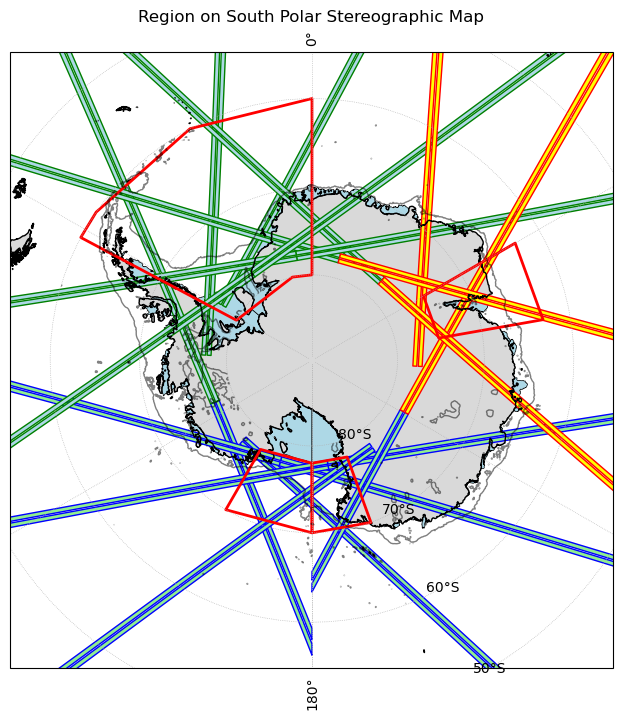

In [92]:
# =============================================================================
# Plot map with defined region
# =============================================================================

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import box
from shapely.ops import unary_union


# -----------------------------
# Plot on Polar Stereographic map
# -----------------------------
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.SouthPolarStereo())

# Set map extent (lon_min, lon_max, lat_min, lat_max) in PlateCarree coordinates
ax.set_extent([-180, 180, -90, -55], crs=ccrs.PlateCarree())

# Base features
ax.add_feature(cfeature.LAND, facecolor="0.85")
ax.add_feature(cfeature.OCEAN, facecolor="white")
ax.coastlines(resolution="10m", linewidth=1)
ax.gridlines(draw_labels=True, linewidth=0.5, linestyle=":")
ax.add_feature(ice_shelves, linewidth=0.5,zorder=0)
ax.contour(bathy.x,bathy.y,bathy.z*(-1),levels=[1000],colors='k',transform=ccrs.PlateCarree(),linewidths=1,alpha=0.5)

# Plot region outline (and fill if desired)
ax.add_geometries(
    [box_Weddell],
    crs=ccrs.PlateCarree(),
    facecolor="none",      # change to e.g. "tab:blue" for a fill
    edgecolor="red",
    linewidth=2,
)
ax.add_geometries(
    [box_Ross],
    crs=ccrs.PlateCarree(),
    facecolor="none",      # change to e.g. "tab:blue" for a fill
    edgecolor="red",
    linewidth=2,
)
ax.add_geometries(
    [box_Amery],
    crs=ccrs.PlateCarree(),
    facecolor="none",      # change to e.g. "tab:blue" for a fill
    edgecolor="red",
    linewidth=2,
)

plt.title("Region on South Polar Stereographic Map")

for idx, (index, row) in enumerate(segments_Ross.iterrows()):
    segments_Ross.loc[[index]].plot(ax=ax, edgecolor="blue", facecolor="lightgreen",transform=ccrs.PlateCarree())
    ax.set_extent([-180, 180, -90, -55], crs=ccrs.PlateCarree())

for idx, (index, row) in enumerate(segments_Weddell.iterrows()):
    segments_Weddell.loc[[index]].plot(ax=ax, edgecolor="green", facecolor="lightblue",transform=ccrs.PlateCarree())
    ax.set_extent([-180, 180, -90, -55], crs=ccrs.PlateCarree())

for idx, (index, row) in enumerate(segments_Amery.iterrows()):
    segments_Amery.loc[[index]].plot(ax=ax, edgecolor="red", facecolor="yellow",transform=ccrs.PlateCarree())
    ax.set_extent([-180, 180, -90, -55], crs=ccrs.PlateCarree())

plt.show()


In [33]:
############### Functions #######################
# should put into separate file

def find_time(ID_PASS_value, extended_bbox):
    
    """
    Find the index of the first point in the combined LineString (for the given ID_PASS) 
    that intersects with the extended bounding box.

    Parameters:
    - ID_PASS_value (int): The ID_PASS value for which to find the intersecting point.
    - extended_bbox (Polygon): The extended bounding box to check intersection.

    Returns:
    - int or None: Index of the first intersecting point, or None if no intersection is found.
    """
    nadir_data = gpd.read_file(filepath+"/sph_calval_nadir.zip")

    def join_linestrings(group):
        """Join LineStrings in the order they appear in the file."""
        if len(group) == 1:
            return group.iloc[0].geometry
        else:
            # Combine LineStrings
            return LineString([pt for line in group.geometry for pt in line.coords])

    def index_of_first_point_inside_bbox(line, bbox):
        """Returns the index of the first point of the LineString that falls inside the bounding box."""
        for index, point in enumerate(line.coords):
            if bbox.contains(Point(point)):
                return index
        return 0 # If no point falls inside the bounding box
    
    # Filtering the GeoDataFrame for rows with the given ID_PASS_value
    subset_gdf = nadir_data[nadir_data["ID_PASS"] == ID_PASS_value]
    
    # Joining LineStrings if there are multiple rows with the same ID_PASS
    combined_geometry = join_linestrings(subset_gdf)
    
    # Finding the index of the first point inside the extended bounding box
    index = index_of_first_point_inside_bbox(combined_geometry, extended_bbox)

    time_str=subset_gdf['START_TIME'].iloc[0]
    _, day_num, time_str = time_str.split(" ", 2)
    days = int(day_num)
    time_parts = list(map(int, time_str.split(":")))
    delta = timedelta(days=days-1, hours=time_parts[0], minutes=time_parts[1], seconds=time_parts[2]+index*30) 
    return delta+pd.Timestamp("2023-07-21T05:33:45.768") 

Saving Ross_CalVal_pass4.png
Saving Ross_CalVal_pass6.png
Saving Ross_CalVal_pass6.png
Saving Ross_CalVal_pass8.png
Saving Ross_CalVal_pass8.png
Saving Ross_CalVal_pass9.png
Saving Ross_CalVal_pass10.png
Saving Ross_CalVal_pass11.png
Saving Ross_CalVal_pass11.png
Saving Ross_CalVal_pass13.png
Saving Ross_CalVal_pass13.png
Saving Ross_CalVal_pass15.png


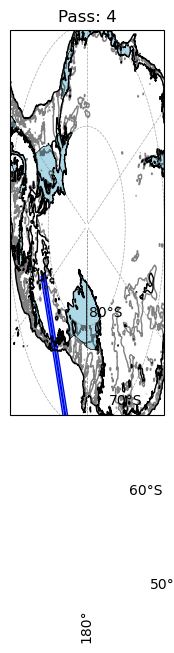

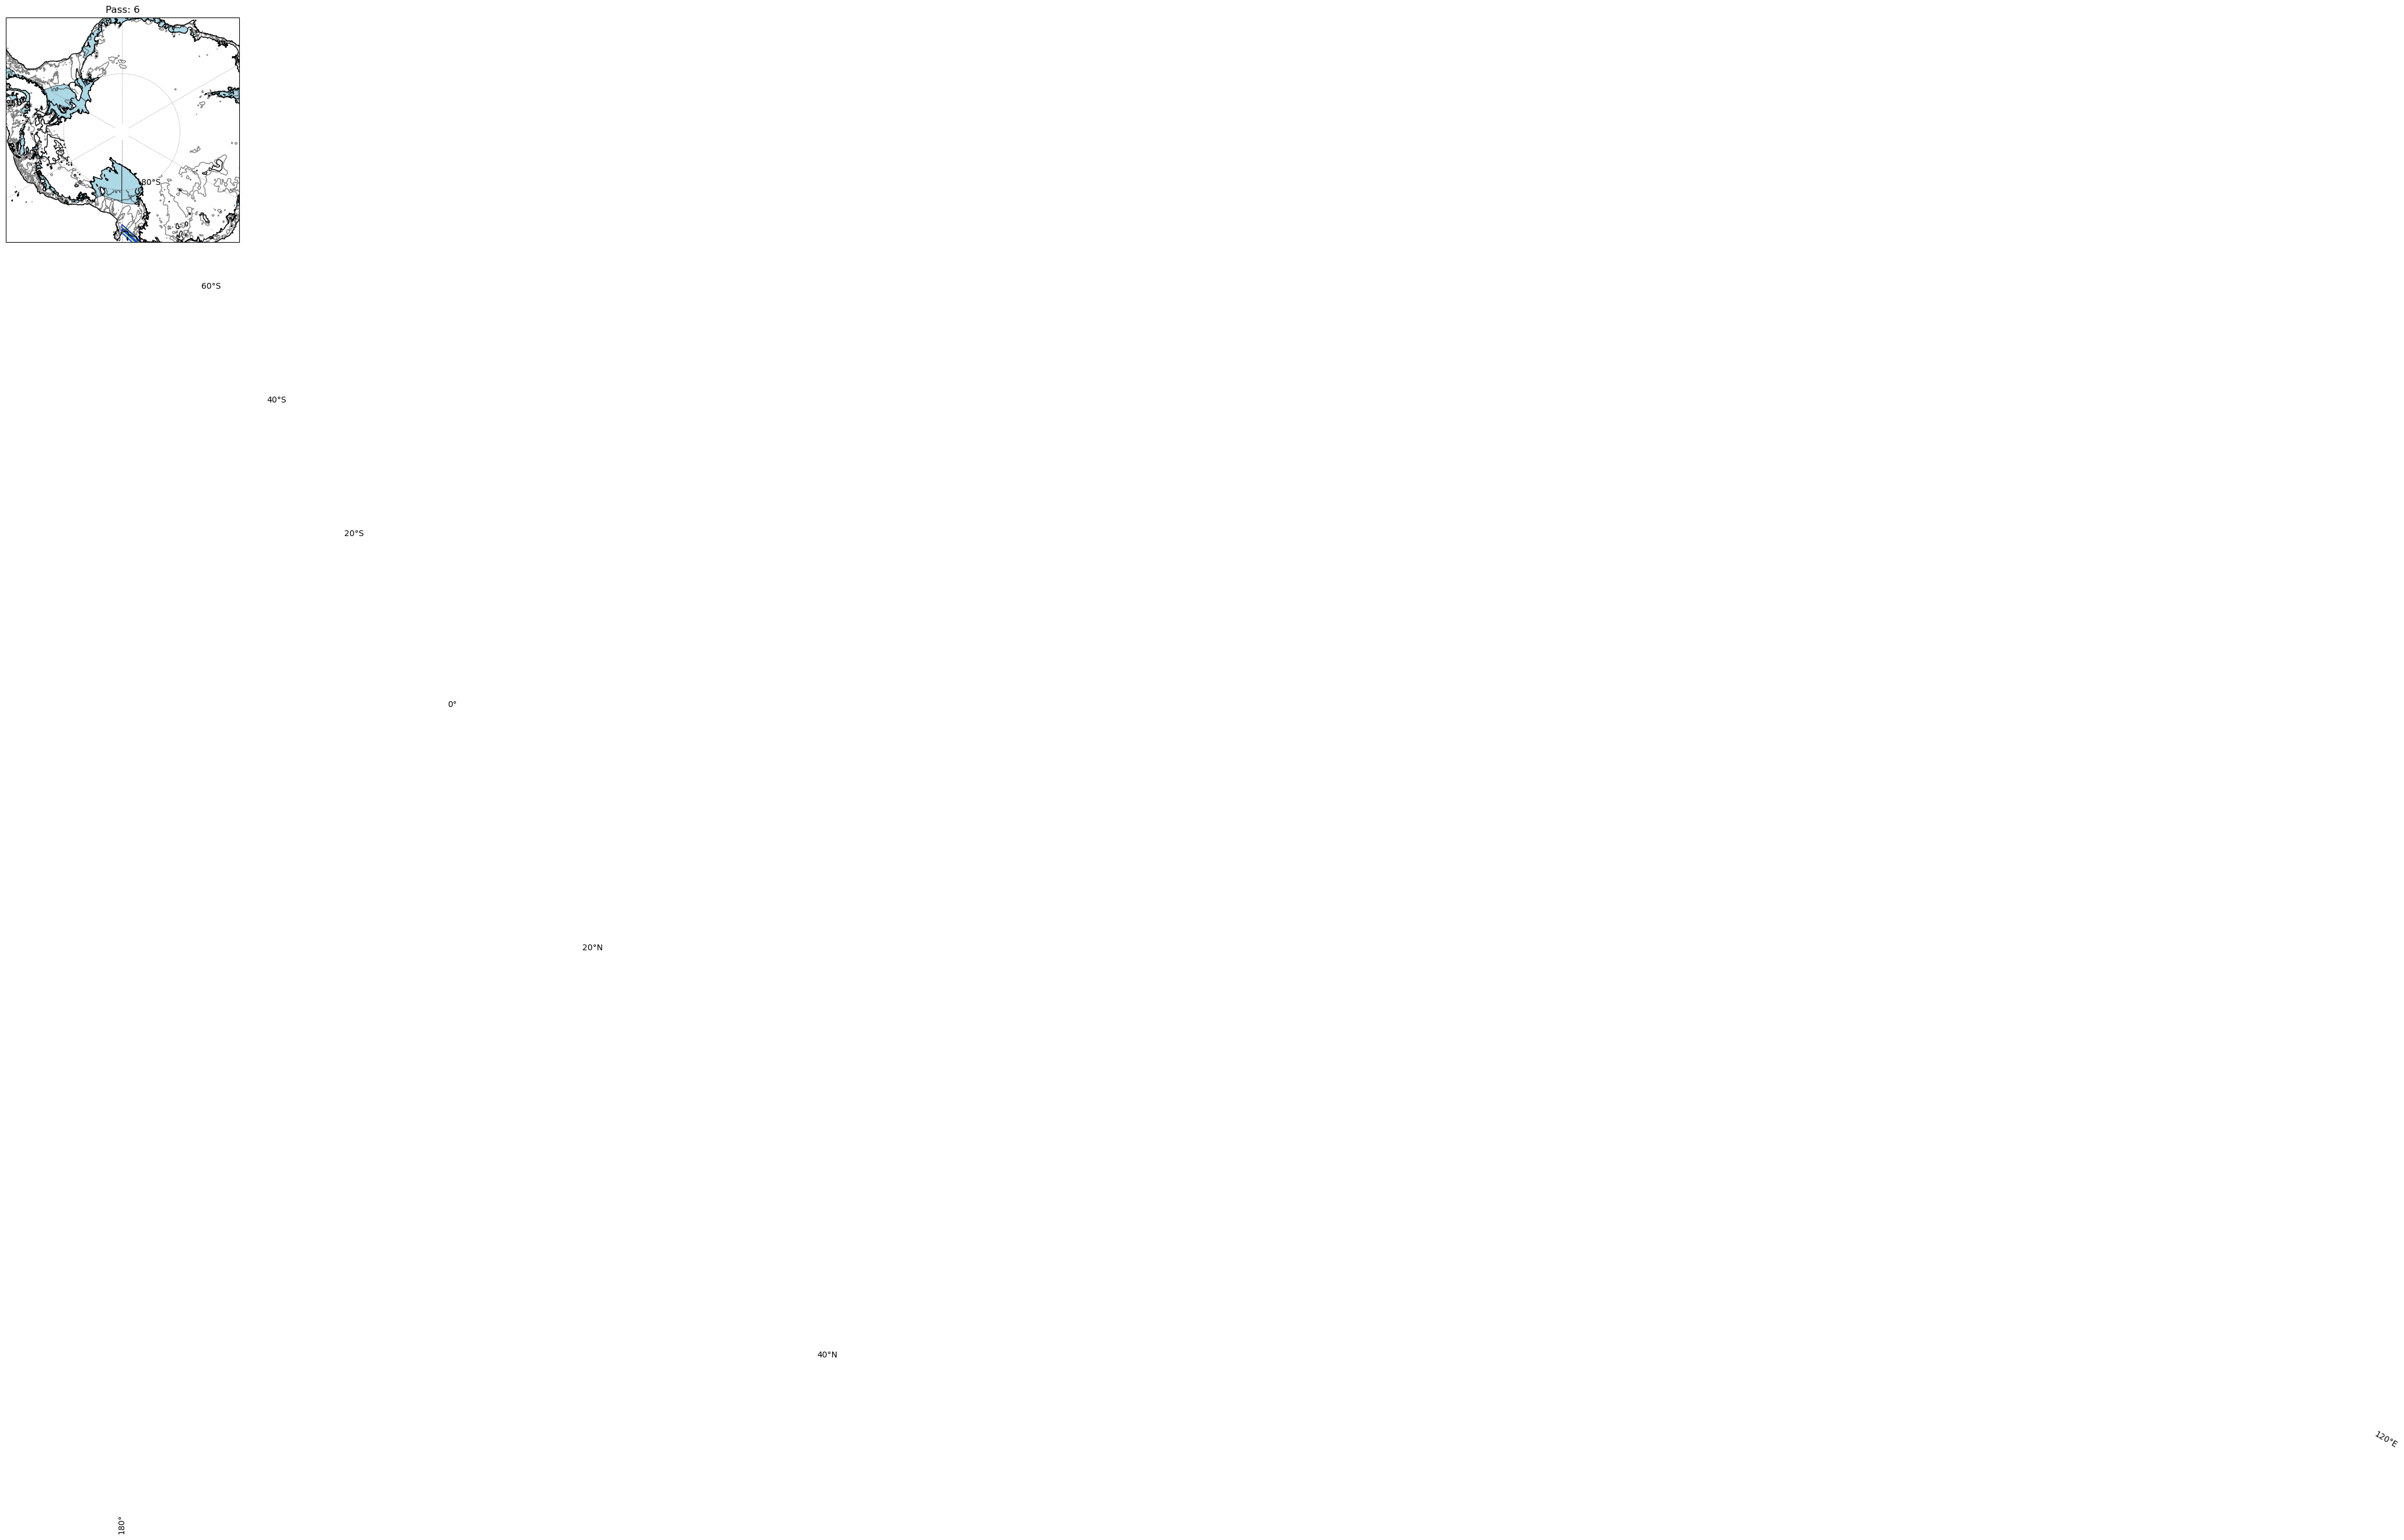

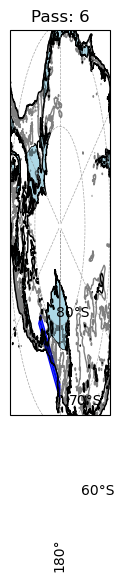

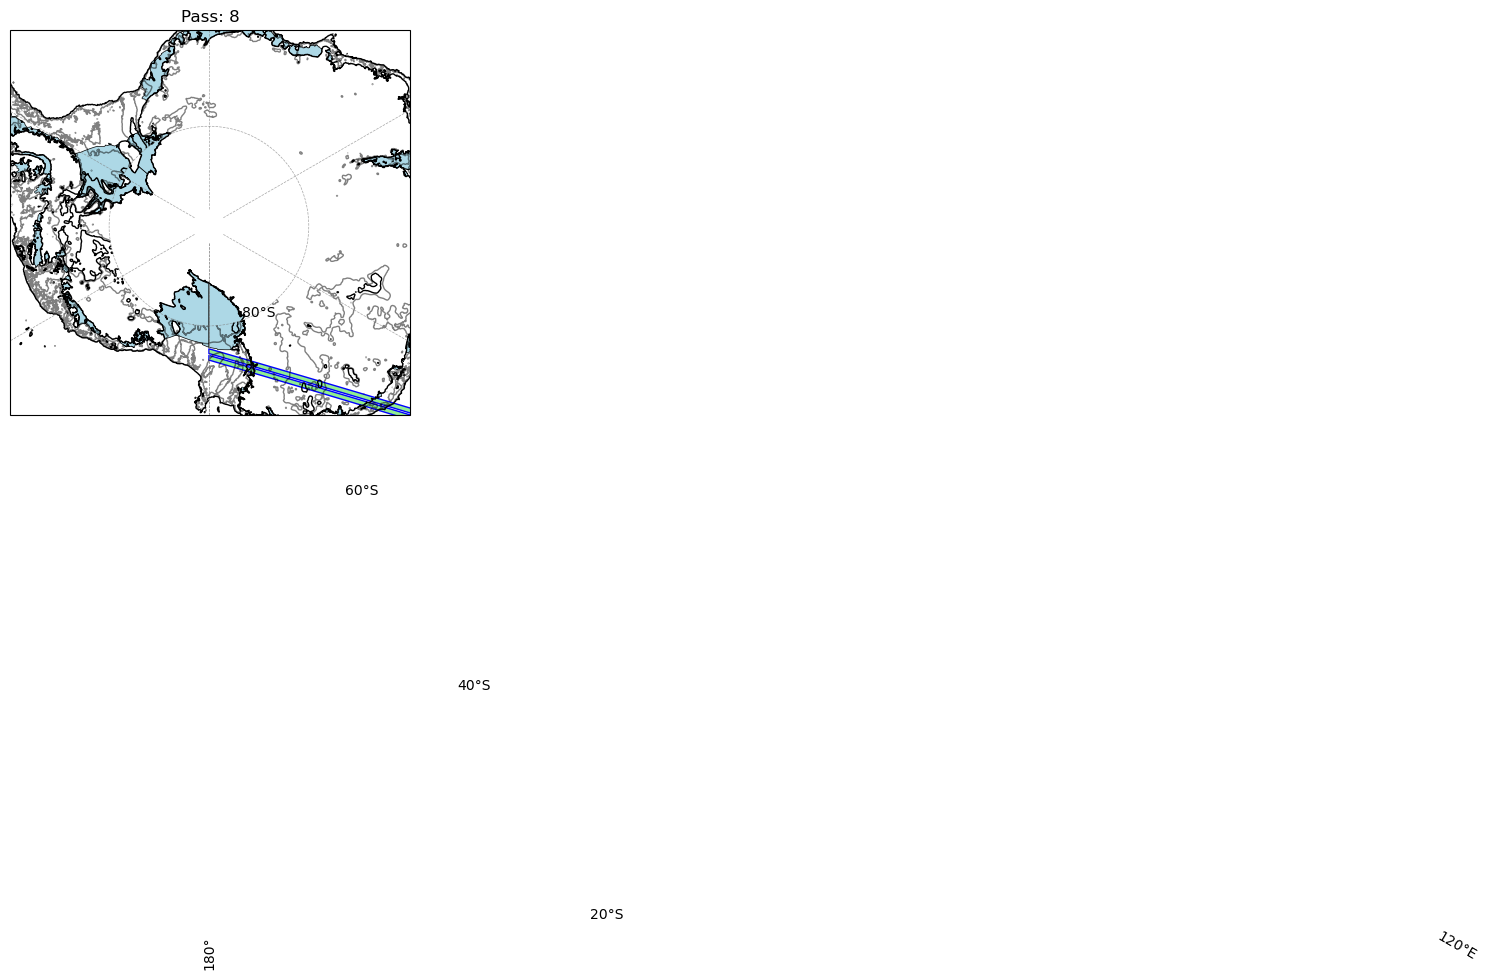

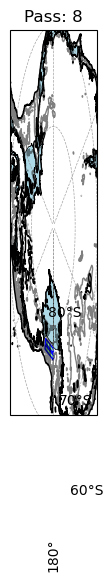

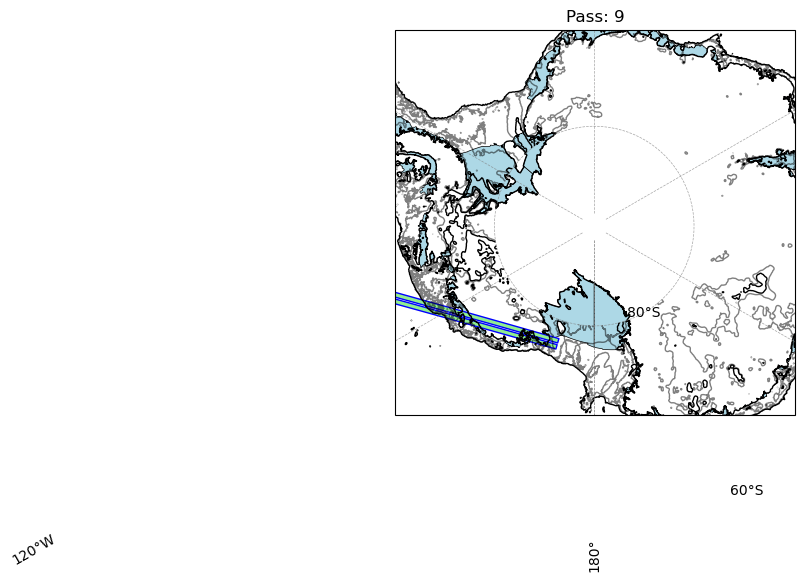

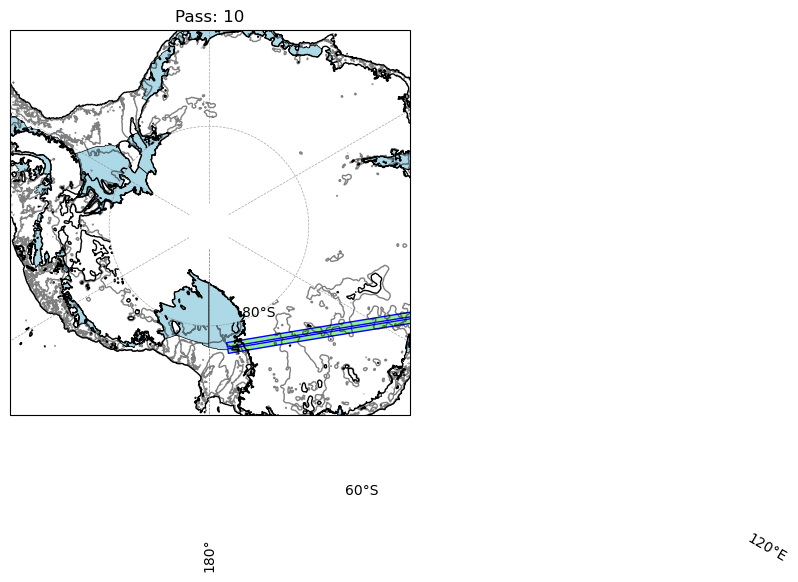

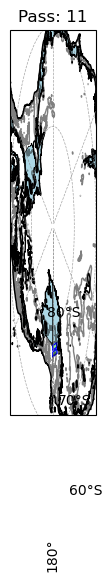

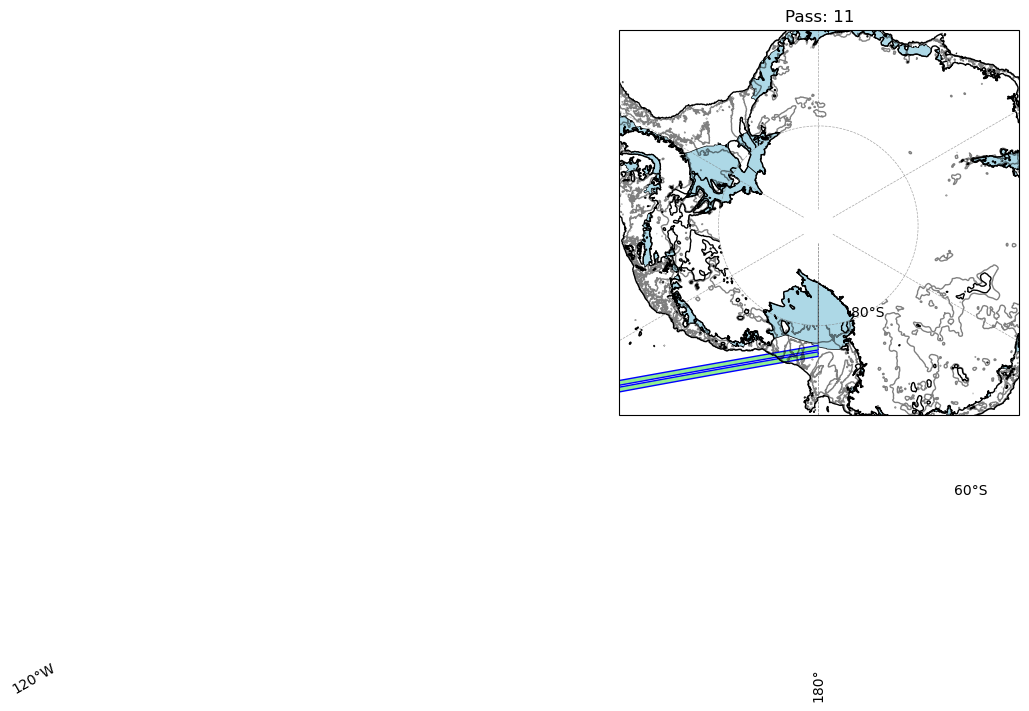

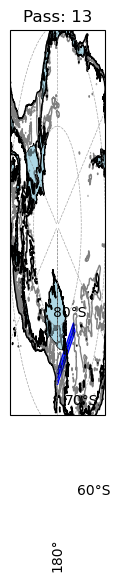

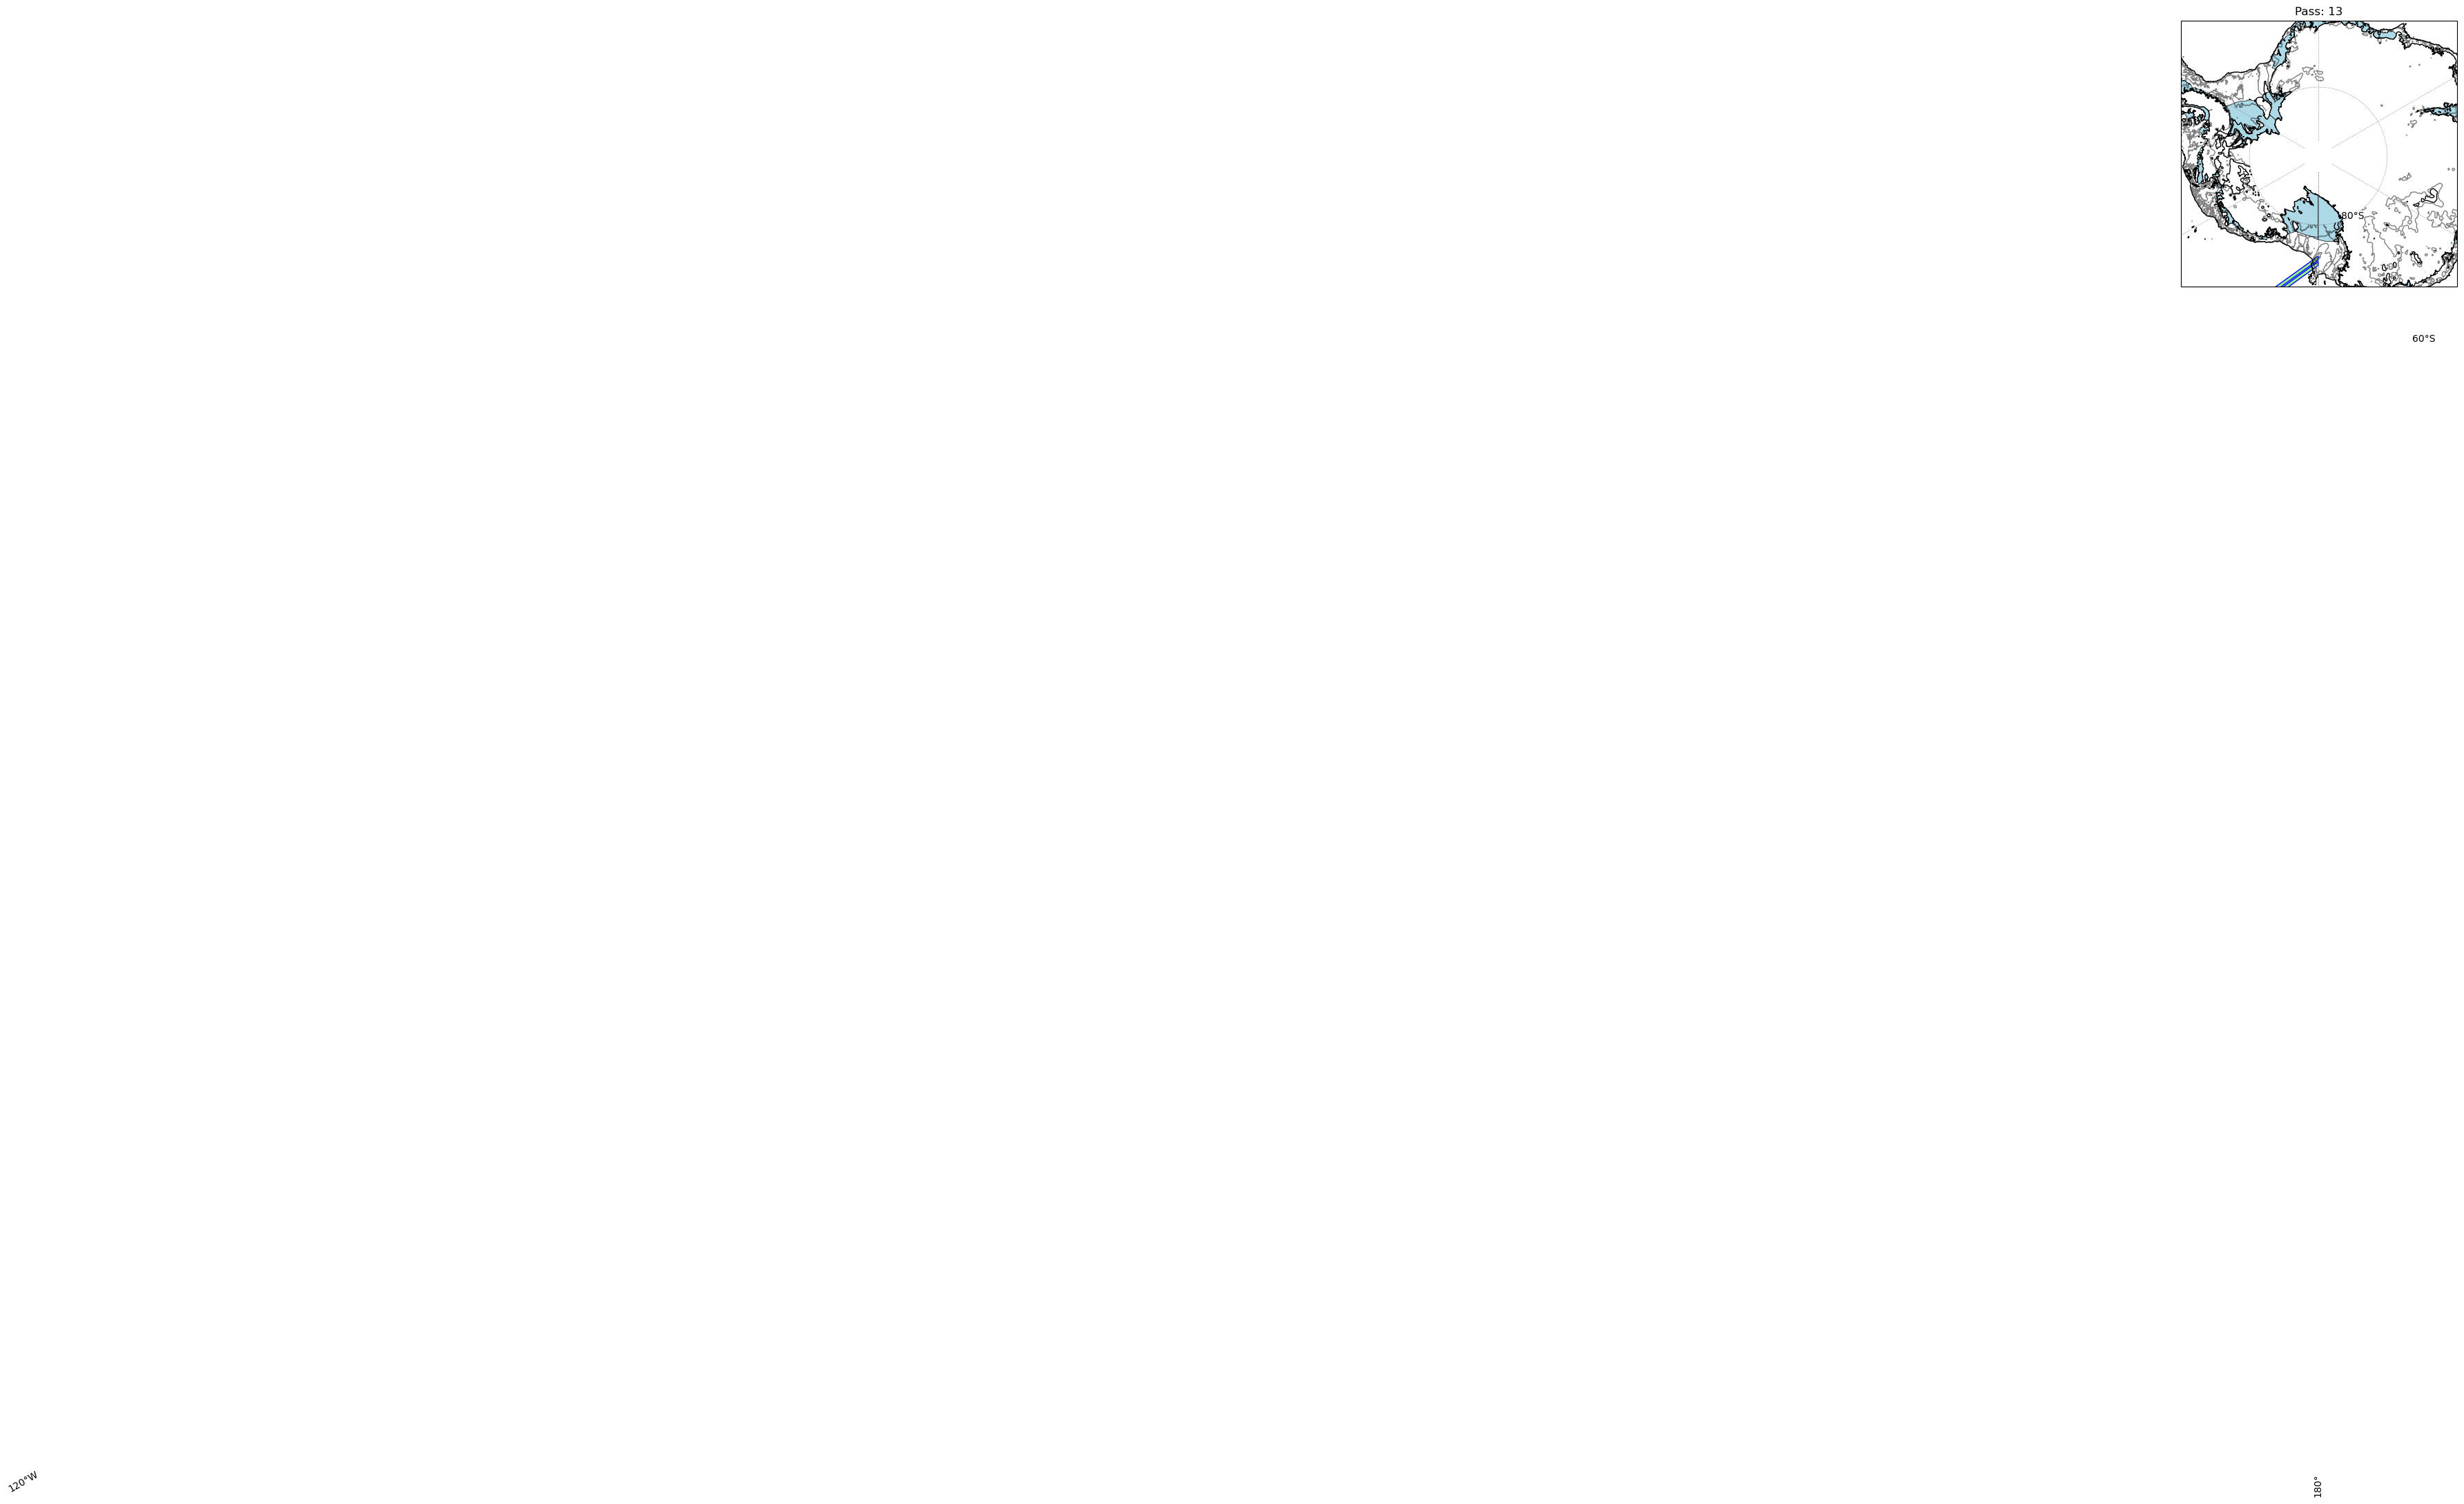

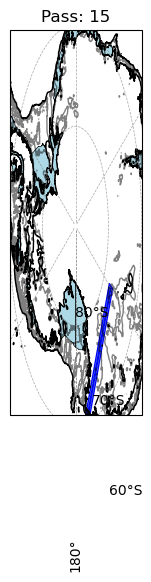

In [126]:
# Print the results on screen
# print(overlapping_segments[["ID_PASS", "TIME_0", "TIME_1", "TIME_2", "TIME_3"]])

# Visualization of the results on a map using Cartopy and saving the figure to output_filename
# Set up the figure and axes with n by 3 subplots


# extract ice shelves for plotting
from cartopy.feature import NaturalEarthFeature
ice_shelves = NaturalEarthFeature(
    category='physical',
    name='antarctic_ice_shelves_polys',
    scale='10m',
    facecolor='lightblue',
    edgecolor='black'
)

# cut bathymetry for faster plotting
# bathy = bathy.sel(x=slice(sw_corner[0],ne_corner[0]),y=slice(sw_corner[1],ne_corner[1]))
    

def plotit(index, ax, row,overlapping_segments,ne_corner,sw_corner):

    # Set the extent of the map
    n_segments = len(overlapping_segments)
    n_rows = (n_segments) // 3

    # Add coastline
    # ax.add_feature(cfeature.GSHHSFeature(scale='low'), facecolor='lightgray',edgecolor='None')
    ax.coastlines(resolution='10m',linewidth=1)
    ax.contour(bathy.x,bathy.y,bathy.z*(-1),levels=[1000],colors='k',transform=ccrs.PlateCarree(),linewidths=1)
    ax.contour(bathy.x,bathy.y,bathy.z*(-1),levels=[500],colors='k',transform=ccrs.PlateCarree(),linewidths=1,alpha=0.5)
    ax.add_feature(ice_shelves, linewidth=0.5,zorder=0)
    
    # Plot the shapefile data
    # gdf.plot(ax=ax, transform=ccrs.PlateCarree())
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                    linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
    gl.top_labels = False  # Disable longitude labels at the top
    gl.right_labels = False  # Disable latitude labels on the right

    # Plot the overlapping segments with light green color
    overlapping_segments.loc[[index]].plot(ax=ax, edgecolor="blue", facecolor="lightgreen",transform=ccrs.PlateCarree())
    ax.set_title(f"Pass: {row['ID_PASS']}")
    ax.set_extent([sw_corner[0], ne_corner[0], sw_corner[1], ne_corner[1]],crs=ccrs.PlateCarree())  # Set extent based on your data's region

    # # Annotate with cycle, pass number, and the four lines of date and time
    # annotation_text = f"Time 0: {row['TIME_0'].strftime('%Y-%m-%d %H:%M:%S')}\n" \
    #                   f"Time 31: {row['TIME_31'].strftime('%Y-%m-%d %H:%M:%S')}"
    
    # ax.annotate(annotation_text, xy=(0.05, 0.1), xycoords='axes fraction', backgroundcolor='white')


####### Plot ###################
def plot_passes(region):
    if region=='Weddell':
        # # # Plot each segment in a separate subplot
        for idx, (index, row) in enumerate(segments_Weddell.iterrows()):
            # ax = axes[idx]
            fig, ax = plt.subplots(figsize=(6,5), subplot_kw={'projection': ccrs.SouthPolarStereo()})
            plotit(index, ax, row,segments_Weddell,ne_corner_Weddell,sw_corner_Weddell)
            finished_plot(fig,f'Weddell_CalVal_pass{row['ID_PASS']}.png')
    elif region=='Ross':
            # # # Plot each segment in a separate subplot
        for idx, (index, row) in enumerate(segments_Ross.iterrows()):
            # ax = axes[idx]
            fig, ax = plt.subplots(figsize=(6,5), subplot_kw={'projection': ccrs.SouthPolarStereo()})
            plotit(index, ax, row,segments_Ross,ne_corner_RossE,sw_corner_RossW)
            finished_plot(fig,f'Ross_CalVal_pass{row['ID_PASS']}.png')
    elif region=='Amery':
        for idx, (index, row) in enumerate(segments_Amery.iterrows()):
            # ax = axes[idx]
            fig, ax = plt.subplots(figsize=(6,5), subplot_kw={'projection': ccrs.SouthPolarStereo()})
            plotit(index, ax, row,segments_Amery,ne_corner_Amery,sw_corner_Amery)
            finished_plot(fig,f'Amery_CalVal_pass{row['ID_PASS']}.png')


plot_passes('Ross')


# Archive

In [121]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

def plot_region_segments(region):
    """
    Plot SWOT segments for a given Antarctic region using subplots.

    Parameters
    ----------
    region : str
        One of ['Weddell', 'Amery', 'Ross']
    """

    # ------------------------------------------------------------------
    # Select region-specific inputs
    # ------------------------------------------------------------------
    if region == "Weddell":
        segments = segments_Weddell
        sw_corner = sw_corner_Weddell
        ne_corner = ne_corner_Weddell

    elif region == "Amery":
        segments = segments_Amery
        sw_corner = sw_corner_Amery
        ne_corner = ne_corner_Amery

    elif region == "Ross":
        segments = segments_Ross
        sw_corner = sw_corner_RossW
        ne_corner = ne_corner_RossE

    else:
        raise ValueError("region must be one of: 'Weddell', 'Amery', 'Ross'")

    # ------------------------------------------------------------------
    # Create subplot grid
    # ------------------------------------------------------------------
    n_segments = len(segments)
    n_rows = int(np.ceil(n_segments / 3))

    fig, ax = plt.subplots(figsize=(10, 10),nrows=n_rows,ncols=3,
                           subplot_kw={"projection": ccrs.SouthPolarStereo()},
                           constrained_layout=True)

    # ------------------------------------------------------------------
    # Plot each segment
    # ------------------------------------------------------------------
    # ravel to loop through axes
    axes = ax.ravel()
    for idx, (index, row) in enumerate(segments.iterrows()):
        plotit(index, axes[idx], row, segments, ne_corner, sw_corner)

    # Hide unused subplots
    for idx in range(n_segments, n_rows * 3):
        axes[idx].axis("off")

    plt.show()
    finished_plot(fig,f'{region}_CalVal_passes_subplot.png')



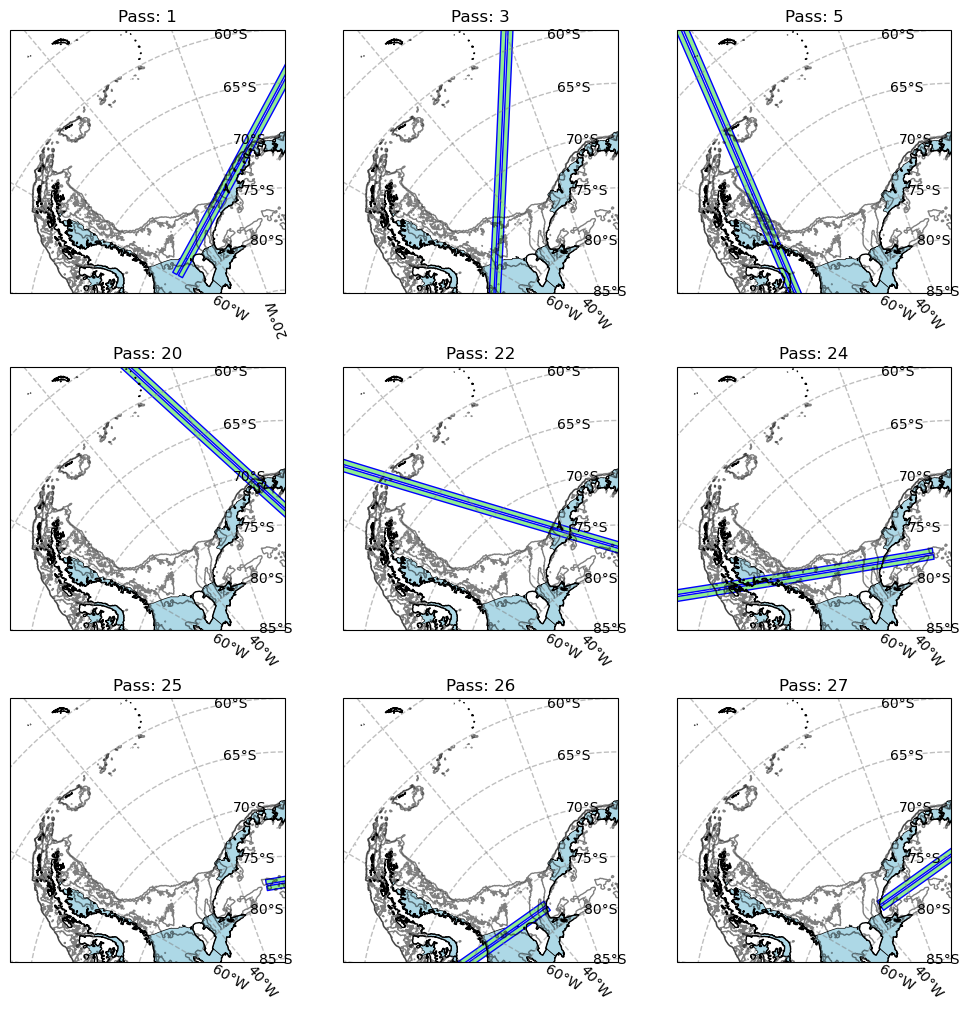

Saving Weddell_CalVal_passes_subplot.png


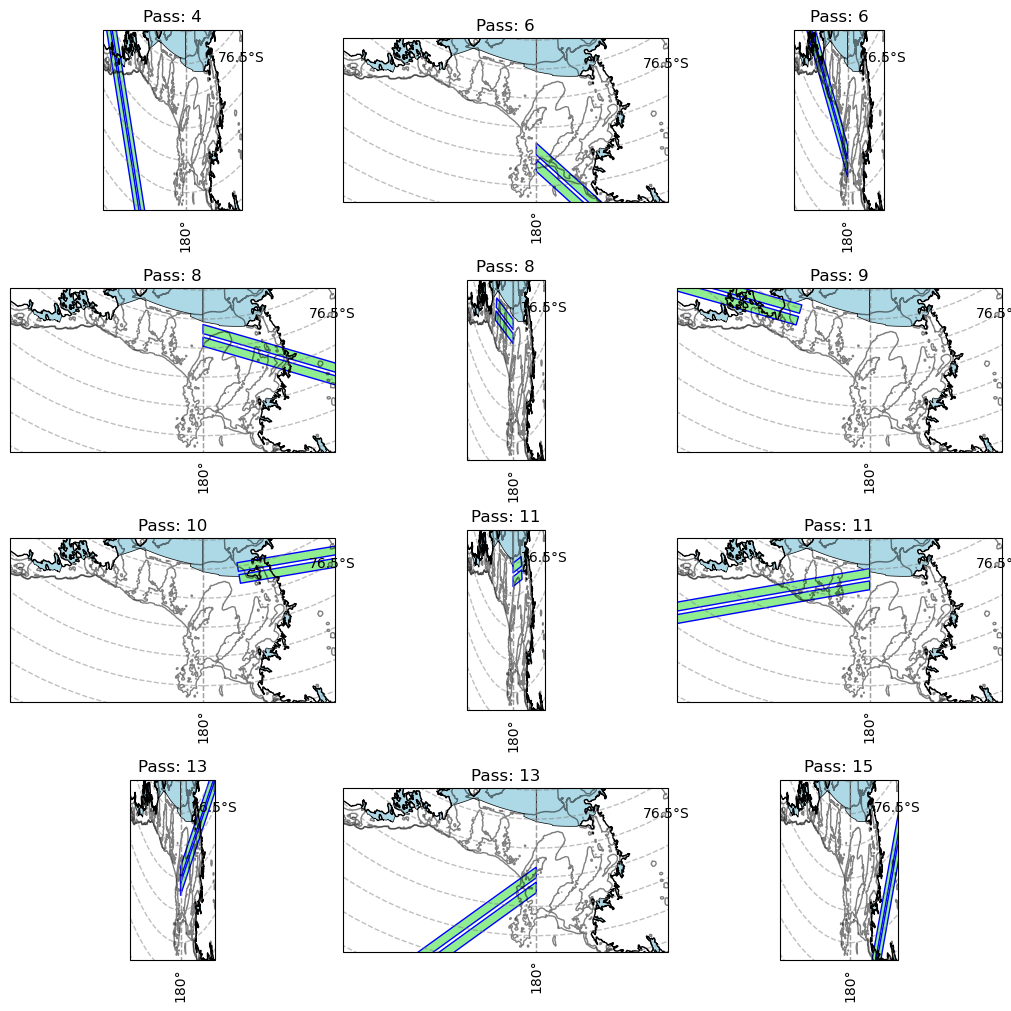

Saving Ross_CalVal_passes_subplot.png


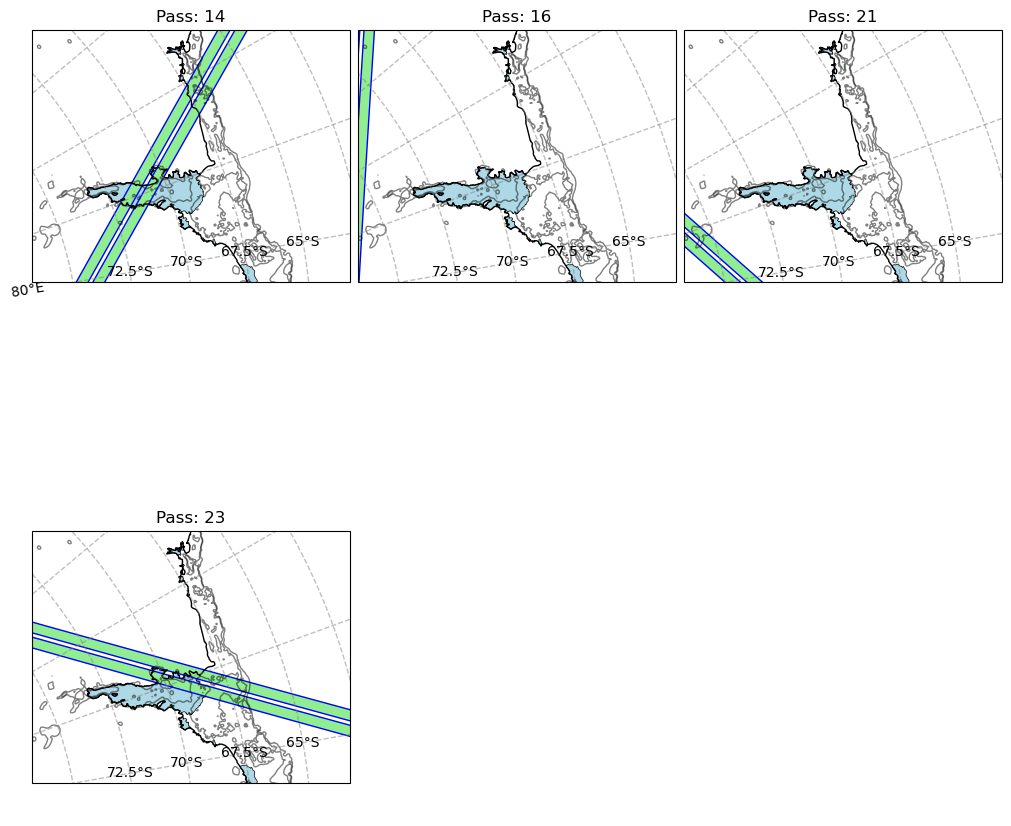

Saving Amery_CalVal_passes_subplot.png


In [122]:
for region in ['Weddell','Ross','Amery']:
    plot_region_segments(region)